In [1]:
import scanpy as sc
import treedata as td
import pycea as py
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import pandas as pd

# Import utility functions made by Katie
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, '/project/imoskowitz/yubin/SmoNull_NMPs_mesoderm_biased_analysis')

from src.I_preprocessing.plot_preprocessing import plot_UMAP_custom

In [ ]:
from src.tree_functions import *

In [3]:
import matplotlib.colors as mcolors
palette_template = mcolors.TABLEAU_COLORS

In [4]:
data_dir = "output_data"
plot_dir = "output_plot"
base_path = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_path_data = base_path+data_dir+"/"
output_path_plot = base_path+plot_dir+"/Trees/Robin_Pijuan/Manual_Cardiac_Annotation/E8_5/"
adata_fname = "Processed_data/E8_5.h5td"

In [5]:
adata = td.read_h5td(output_path_data+"Processed_data/E8_5.h5td")


In [6]:
adata.obs['cardiac_labels'].unique()

[NaN, 'pSHF', 'aSHF', 'Differentiating CM', 'CMs', 'JCF']
Categories (5, object): ['CMs', 'Differentiating CM', 'JCF', 'aSHF', 'pSHF']

In [7]:
adata.X = adata.layers["raw_counts"]

In [8]:
adata.obs['cardiac_labels'] = adata.obs['cardiac_labels'].astype('category')
adata.obs['tree'] = adata.obs['tree'].astype('category')
adata.obs['germ_layer'] = adata.obs['germ_layer'].astype('category')

In [9]:
tree_sizes = adata.obs['tree'].value_counts().sort_values(ascending=False)
print(tree_sizes.head(10))

# flag trees likely to be memory-heavy (dense O(n^2) LCA matrix)
LARGE_TREE_THRESHOLD = 2000  # adjust based on what crashed before
large_trees = tree_sizes[tree_sizes > LARGE_TREE_THRESHOLD].index.tolist()
print("Large trees (may need special handling):", large_trees)

tree
E8.5-R3-C1    19886
E8.5-R2-C1    15318
E8.5-R2-C2    12352
E8.5-R1-C1     6192
E8.5-R3-C2     4202
E8.5-R1-C3     2955
E8.5-R1-C2     2256
E8.5-R3-C3      664
E8.5-R1-C4      429
Name: count, dtype: int64
Large trees (may need special handling): ['E8.5-R3-C1', 'E8.5-R2-C1', 'E8.5-R2-C2', 'E8.5-R1-C1', 'E8.5-R3-C2', 'E8.5-R1-C3', 'E8.5-R1-C2']


#### Pick a subset of cells that you want to plot

In [10]:
# E8.5 with Colgan Auto Annotation
# Cardiac_cell_types = {"Juxtacardiac field" : "Juxtacardiac field",
#                         "First heart field": "First heart field",
#                         "Second heart field": "Second heart field",
#                         "Anterior mesoderm": "anterior second heart field" 
#                       }

### Functions

In [11]:
def get_color_palette(adata, color_key, palette=None, default_cmap="tab10"):
    """
    Build a {category: color} dict for adata.obs[color_key], staying consistent
    with any existing palette saved in adata.uns, and always including gray
    for NaN / missing values.

    Parameters
    ----------
    adata
        AnnData / TreeData object
    color_key : str
        obs column to build colors for
    palette : str | list | dict | None
        - None: look for adata.uns[f"{color_key}_colors"] first (scanpy convention);
          if not found, generate from `default_cmap`
        - str: either a key in adata.uns (a saved palette) or a matplotlib
          colormap name (e.g. "tab10", "tab20", "Set2")
        - list: ordered colors, zipped with sorted categories
        - dict: explicit mapping; any categories it's missing get auto-filled

    Returns
    -------
    dict mapping category -> color, plus "mixed" and NaN entries
    """
    categories = adata.obs[color_key].astype("category").cat.categories.tolist()
    resolved = {}

    if isinstance(palette, dict):
        resolved = dict(palette)
    elif isinstance(palette, list):
        resolved = dict(zip(categories, palette))
    elif isinstance(palette, str):
        if palette in adata.uns:
            resolved = dict(zip(categories, adata.uns[palette]))
        else:
            cmap = plt.get_cmap(palette)
            resolved = {cat: cmap(i % cmap.N) for i, cat in enumerate(categories)}
    elif palette is None:
        uns_key = f"{color_key}_colors"
        if uns_key in adata.uns:
            resolved = dict(zip(categories, adata.uns[uns_key]))
        else:
            cmap = plt.get_cmap(default_cmap)
            resolved = {cat: cmap(i % cmap.N) for i, cat in enumerate(categories)}

    # fill any categories still missing a color (e.g. dict/list didn't cover all)
    cmap = plt.get_cmap(default_cmap)
    for i, cat in enumerate(categories):
        if cat not in resolved:
            resolved[cat] = cmap(i % cmap.N)

    # reserved, always-consistent entries
    resolved["mixed"] = (0.6, 0.6, 0.6, 1.0)
    resolved[np.nan] = "lightgray"
    resolved["nan"] = "lightgray"   # covers the common case where obs got cast to str

    return resolved

In [12]:
def compute_lca_depth_points(clone_tdata, clone_key, color, n_leaf=5):
    """
    Computes sliding-window LCA depth stats for each cell type.

    Returns
    -------
    points : list of (depth, leaf_position, celltype) tuples
    depth_count : dict {celltype: {depth: count}}
    leaf_order : list of leaf names
    valid_types : list of valid (non-NaN) cell type labels
    """
    py.tl.tree_distance(clone_tdata, tree=clone_key, metric="lca", key_added="lca")
    lca_depths = clone_tdata.obsp["lca_distances"]
    if hasattr(lca_depths, "toarray"):
        lca_depths = lca_depths.toarray()

    leaf_order = py.get.leaves(clone_tdata, tree=clone_key)
    n = len(leaf_order)

    # Precompute leaf -> row/col index once
    leaf_idx_map = {name: i for i, name in enumerate(clone_tdata.obs_names)}
    leaf_indices = np.array([leaf_idx_map[leaf] for leaf in leaf_order])

    # Reorder the full LCA matrix to leaf_order once
    lca_leaf = lca_depths[np.ix_(leaf_indices, leaf_indices)]

    cell_types = clone_tdata.obs.loc[leaf_order, color].astype(str).to_numpy()
    valid_types = [ct for ct in np.unique(cell_types) if ct not in {"nan", "None", "", "<NA>"}]

    # Assign each leaf a window id, build one small dataframe to group by (window, cell_type)
    window_id = np.arange(n) // n_leaf
    df = pd.DataFrame({"window_id": window_id, "cell_type": cell_types, "pos": np.arange(n)})
    df = df[df["cell_type"].isin(valid_types)]

    # Only windows with >=2 total leaves are valid (matches original's window-level skip)
    window_sizes = pd.Series(window_id).value_counts()
    valid_windows = set(window_sizes[window_sizes >= 2].index)

    points = []
    depth_count = {ct: {} for ct in valid_types}

    # groupby only visits (window, cell_type) pairs that actually occur —
    # no wasted iterations over empty combinations
    for (w, ct), group in df.groupby(["window_id", "cell_type"], sort=False):
        if w not in valid_windows or len(group) < 2:
            continue
        idx = group["pos"].to_numpy()
        middle_pos = min(w * n_leaf + 2, n - 1)

        sub = lca_leaf[np.ix_(idx, idx)]
        tri = np.triu_indices(len(idx), k=1)
        pair_depths = sub[tri]
        ancestor_depth = float(pair_depths.min()) if pair_depths.size else 0.0

        points.append((ancestor_depth, middle_pos, ct))
        depth_count[ct][ancestor_depth] = depth_count[ct].get(ancestor_depth, 0) + 1

    return points, depth_count, leaf_order, valid_types


def plot_depth_dotplot(ax_points, points, valid_types, palette, leaf_order):
    """
    Scatter plot of sliding-window ancestor depth vs leaf order, colored by cell type.
    """
    for ct in valid_types:
        subset = [p for p in points if p[2] == ct]
        if not subset:
            continue
        xs = [p[0] for p in subset]
        ys = [p[1] for p in subset]
        ax_points.scatter(xs, ys, color=palette.get(ct, "black"), s=40, alpha=0.8, label=ct)

    x_max = max([p[0] for p in points], default=1.0)
    ax_points.set_xlim(0, x_max + 1)
    ax_points.set_ylim(0, len(leaf_order) - 1)
    ax_points.set_xlabel("Ancestor depth")
    ax_points.set_ylabel("Leaf order (bottom -> top)")
    ax_points.set_title("Sliding-window ancestor-depth", fontsize=14)
    ax_points.grid(alpha=0.2)
    ax_points.legend(loc="lower left", frameon=False)

    return ax_points


def plot_depth_histogram(ax_points, depth_count, valid_types, palette):
    """
    Overlays a step histogram of ancestor-depth counts per cell type on a
    twin y-axis of ax_points. Returns the twin axis (ax_hist).
    """
    all_counts = [count for ct in valid_types for count in depth_count[ct].values()]
    max_count = max(all_counts, default=1)

    ax_hist = ax_points.twinx()

    for ct in valid_types:
        if not depth_count.get(ct):
            continue
        depths = list(depth_count[ct].keys())
        counts = list(depth_count[ct].values())
        if len(depths) == 1:
            bins = np.arange(min(depths) - 0.5, max(depths) + 1.5, 1)
        else:
            bins = np.arange(0, max(depths) + 2, 1)
        ax_hist.hist(
            depths,
            bins=bins,
            weights=counts,
            histtype='step',
            color=palette.get(ct, "black"),
            edgecolor=palette.get(ct, "black"),
            label=f"{ct} counts",
            stacked=True
        )

    ax_hist.set_ylim(0, max_count * 10)
    ax_hist.set_ylabel("Histogram share (scaled)")
    ax_hist.set_yticks([])

    return ax_hist



In [13]:
def plot_tree_custom(clone_tdata,
                     clone_key,
                     color,
                     palette: None | str | list = None,
                     n_leaf=5,
                     output_path_plot: str | None = None
):
    """
    Given a tdata with obst, plots:
        - the tree labeling the leaf by specified color,
        - the branch with the color of the common descendent color and grayed when descendent color are not the same.
        - dotplot of the average depth of each color within n_leaf,
        - with a histogram summarizing the depth counts

    Parameters
    ----------
    clone_tdata (tdata)
        tdata containing lineage tree
    clone_key (str)
        name for the lineage tree
    color (str)
        obs name for the cell/leaf to be colored by
    palette (str | list | None)
        color palette for the obs. If None, attempt to find the default color in .uns
    n_leaf
        Number of leaf to cluster by to calculate the average depth of. This range will be iterated from the top to the bottom of the tree
    output_path_plot
        Saving plot on file location. If None, show plot instead.

    Returns
    -------
    dict with keys:
        "ax_tree"     : the tree axis (only meaningful if output_path_plot is None)
        "points"      : list of (depth, leaf_position, celltype) tuples
        "depth_count" : dict {celltype: {depth: count}}
        "leaf_order"  : list of leaf names
        "valid_types" : list of valid (non-NaN) cell type labels
    """
    from matplotlib import gridspec

    # Taking care of the palette
    palette = get_color_palette(clone_tdata, color_key=color, palette=palette)

    add_obs_to_tree(clone_tdata, keys=[color, "germ_layer"])
    py.pp.add_depth(clone_tdata)
    py.tl.ancestral_states(clone_tdata, keys=color, tree=clone_key, method="mode")
    flag_mixed_nodes(clone_tdata, clone_key, cell_type_key=color)
    add_node_attrs_to_edges(clone_tdata, keys=[color, "germ_layer"])

    # LCA depth computation — computed once, returned for reuse downstream
    points, depth_count, leaf_order, valid_types = compute_lca_depth_points(
        clone_tdata, clone_key, color, n_leaf=n_leaf
    )

    # Create a tree panel and a right-side point panel
    fig = plt.figure(figsize=(16, 40))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3, 2], wspace=0.08)
    ax_tree = fig.add_subplot(gs[0])
    ax_points = fig.add_subplot(gs[1])

    pos = ax_points.get_position()
    new_bottom = 0.121
    new_height = 0.748
    ax_points.set_position([pos.x0, new_bottom, pos.width, new_height])

    # Plotting Tree
    py.pl.branches(
        clone_tdata,
        depth_key="depth",
        color=color,
        palette=palette,
        extend_branches=True,
        angled_branches=True,
        tree=clone_key,
        legend=False,
        ax=ax_tree,
    )
    py.pl.nodes(
        clone_tdata,
        color=color,
        palette=palette,
        nodes="leaves",
        size=10,
        legend=False,
        tree=clone_key,
        ax=ax_tree,
    )
    ax_tree.set_title(f"Lineage tree — {clone_key}", fontsize=14)

    # Dotplot
    plot_depth_dotplot(ax_points, points, valid_types, palette, leaf_order)

    # Histogram overlay
    plot_depth_histogram(ax_points, depth_count, valid_types, palette)

    plt.tight_layout()
    if output_path_plot is None:
        plt.show()
        result_ax = ax_tree
    else:
        plt.savefig(output_path_plot + clone_key + "_tree_with_scatter_histogram.svg", bbox_inches='tight')
        result_ax = None
    plt.close(fig)

    return {
        "ax_tree": result_ax,
        "points": points,
        "depth_count": depth_count,
        "leaf_order": leaf_order,
        "valid_types": valid_types,
    }

In [ ]:
import gc

output_csv = output_path_plot + "depth_points_all_trees.csv"
csv_path = Path(output_csv)
if csv_path.exists():
    csv_path.unlink()  # start fresh; remove if you want to append across runs

for clone_key in adata.obs['tree'].unique():
    if pd.isna(clone_key) or clone_key == 'nan': # To catch cells that do not have a tree
        continue

    n_cells = tree_sizes.get(clone_key, 0)
    print(f"starting {clone_key} ({n_cells} cells)")

    clone_tdata = adata[adata.obs["tree"] == clone_key].copy()

    # plotting + LCA computation happen once, together
    result = plot_tree_custom(clone_tdata, clone_key, color="cardiac_labels", output_path_plot=output_path_plot)

    points = result["points"]
    leaf_order = result["leaf_order"]

    rows = [{"tree": clone_key, "cell_type": ct, "depth": d, "pos": p, "n_leaves": len(leaf_order)}
            for d, p, ct in points]
    df_chunk = pd.DataFrame(rows)
    df_chunk.to_csv(output_csv, mode='a', header=not csv_path.exists(), index=False)

    # explicit cleanup
    del clone_tdata, result, points, df_chunk
    gc.collect()

    print(f"complete {clone_key}")

plt.close('all')  # belt-and-suspenders in case anything else left a figure open

starting E8.5-R1-C1 (6192 cells)


/scratch/local/jobs/52281737/ipykernel_4080706/2268943126.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


complete E8.5-R1-C1
starting E8.5-R1-C2 (2256 cells)


/scratch/local/jobs/52281737/ipykernel_4080706/2268943126.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


complete E8.5-R1-C2
starting E8.5-R1-C3 (2955 cells)


/scratch/local/jobs/52281737/ipykernel_4080706/2268943126.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


complete E8.5-R1-C3
starting E8.5-R1-C4 (429 cells)


/scratch/local/jobs/52281737/ipykernel_4080706/2268943126.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


complete E8.5-R1-C4
starting E8.5-R3-C1 (19886 cells)


In [ ]:
ct = pd.crosstab(adata.obs['tree'], adata.obs['cardiac_labels'], normalize='index') * 100
ct.round(1)

cardiac_labels,CM,Differentiating CM,JCF,aSHF,pSHF
tree,,,,,
E8.0-R1-C1,4.2,33.8,16.0,24.0,22.1
E8.0-R1-C2,4.4,15.6,28.9,14.4,36.7
E8.0-R1-C3,5.8,21.2,11.5,28.8,32.7
E8.0-R2-C1,27.5,22.9,8.4,13.1,28.1
E8.0-R2-C2,32.8,20.6,7.0,6.6,33.1
E8.0-R3-C1,19.9,21.2,6.9,18.6,33.3
E8.0-R3-C2,15.8,38.9,10.1,11.7,23.5
E8.0-R3-C3,33.0,21.1,5.5,21.1,19.3
E8.0-R3-C4,10.5,21.1,21.1,13.2,34.2


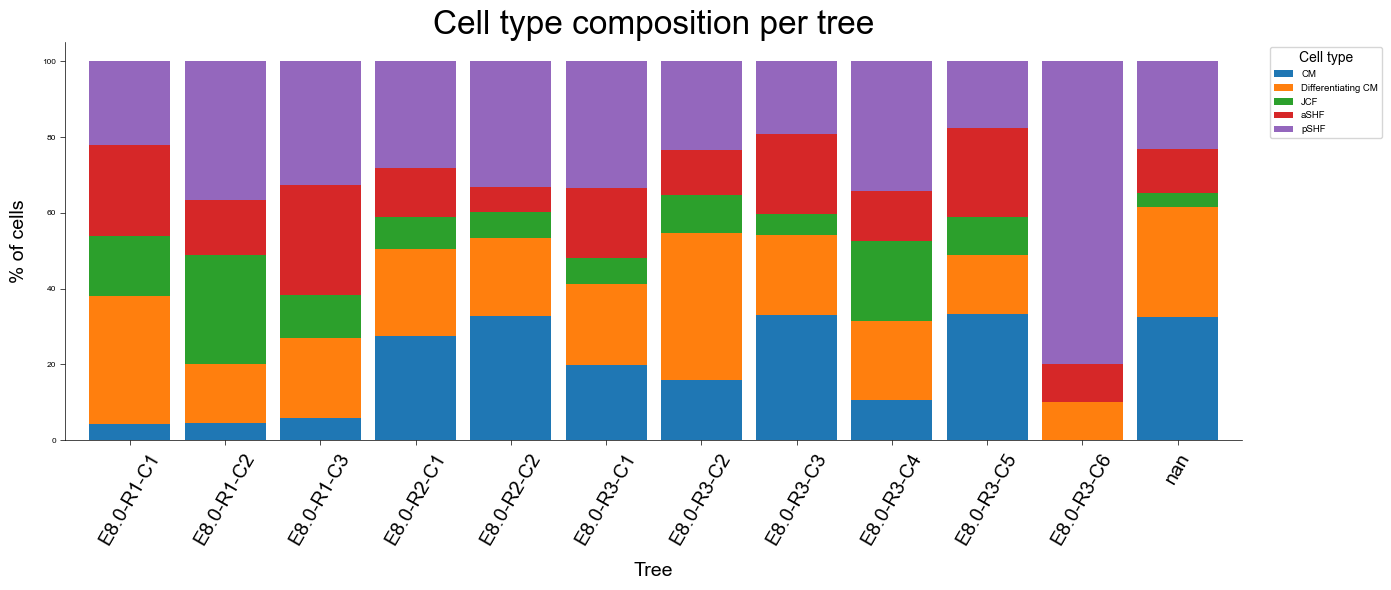

In [ ]:
palette = get_color_palette(adata, color_key='cardiac_labels')
colors = [palette.get(ct, "gray") for ct in ct.columns]

ax = ct.plot(kind='bar', stacked=True, figsize=(14, 6), color=colors, width=0.85)
ax.set_ylabel("% of cells", size = 14)
ax.set_xlabel("Tree", size = 14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='center', fontsize=14)
ax.set_title("Cell type composition per tree", size = 24)
ax.legend(title="Cell type", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(output_path_plot + "cardiac_celltype_composition_per_tree.svg", bbox_inches='tight')